# Flow Matching Lab: MNIST Digits and EITZ Sketches


In [1]:
!git clone https://github.com/jmsaavedrar/flow_and_diffusion

fatal: destination path 'flow_and_diffusion' already exists and is not an empty directory.


## Plan for this lab
1. Set up the libraries we need.
2. Look at the MNIST digits and the noise we start from.
3. Train a small neural network with the flow matching loss.
4. Use the trained model to sample new digits.


In [2]:
import sys
import torch
from torch import nn
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

sys.path.append("mnist")

import mnistutils as util
import unet

class MNISTSampler(nn.Module, util.Sampleable):
    def __init__(self):
        super().__init__()
        self.dataset = datasets.MNIST(
            root="./data",
            train=True,
            download=True,
            transform=transforms.Compose([
                transforms.Resize((32, 32)),
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,)),
            ])
        )
        self.register_buffer("device_ref", torch.zeros(1))

    def sample(self, num_samples: int):
        if num_samples > len(self.dataset):
            raise ValueError(f"num_samples exceeds dataset size: {len(self.dataset)}")
        indices = torch.randperm(len(self.dataset))[:num_samples]
        samples, labels = zip(*[self.dataset[i] for i in indices])
        samples = torch.stack(samples).to(self.device_ref.device)
        labels = torch.tensor(labels, dtype=torch.int64, device=self.device_ref.device)
        return samples, labels

class Gaussian(nn.Module, util.Sampleable):
    def __init__(self, shape, std: float = 1.0):
        super().__init__()
        self.shape = shape
        self.std = std
        self.register_buffer("device_ref", torch.zeros(1))

    def sample(self, num_samples: int):
        noise = self.std * torch.randn(num_samples, *self.shape, device=self.device_ref.device)
        return noise, None

class ProbabilityPath(util.ConditionalProbabilityPath):
    def __init__(self, p_data, p_simple_shape, alpha, beta):
        super().__init__(Gaussian(p_simple_shape), p_data)
        self.alpha = alpha
        self.beta = beta

    def sample_conditioning_variable(self, num_samples):
        return self.p_data.sample(num_samples)

    def sample_conditional_path(self, z, t):
        return self.alpha(t) * z + self.beta(t) * torch.randn_like(z)

    def conditional_vector_field(self, x, z, t):
        alpha_t = self.alpha(t)
        beta_t = self.beta(t)
        dt_alpha_t = self.alpha.dt(t)
        dt_beta_t = self.beta.dt(t)
        return (dt_alpha_t - dt_beta_t / beta_t * alpha_t) * z + dt_beta_t / beta_t * x

    def conditional_score(self, x, z, t):
        alpha_t = self.alpha(t)
        beta_t = self.beta(t)
        return (z * alpha_t - x) / beta_t ** 2

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} for training and sampling.")

Using cuda for training and sampling.


### Inspect the data and the starting noise
The first time you run the next cell it will download the MNIST digits (~12 MB).
Our goal is to turn simple noise into real digits. First look at a few samples from the MNIST dataset.


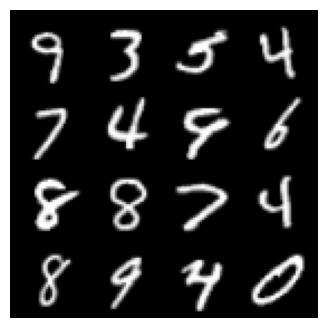

In [3]:
data_sampler = MNISTSampler().to(device)
digits, labels = data_sampler.sample(16)
grid = make_grid(digits, nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
plt.show()

The model starts from Gaussian noise. The probability path below smoothly moves this noise toward real digits.


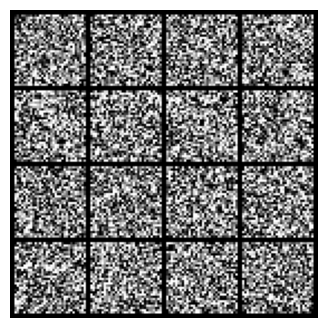

In [4]:
path = ProbabilityPath(
    p_data=data_sampler,
    p_simple_shape=[1, 32, 32],
    alpha=util.LinearAlpha(),
    beta=util.LinearBeta()
).to(device)

noise, _ = path.p_simple.sample(16)
noise_grid = make_grid(noise, nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(4, 4))
plt.imshow(noise_grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
plt.show()

### Build the flow model
We use a small U-Net that reads the current image, the time $t$, and an optional digit label. Flow matching trains it to predict how the image should move at each step.


In [5]:
net = unet.MNISTUNet(
    channels=[32, 64, 128],
    num_residual_layers=2,
    t_embed_dim=40,
    y_embed_dim=40,
).to(device)

param_count = sum(p.numel() for p in net.parameters())
print(f"Model size: {param_count / 1e6:.2f} million parameters")

Model size: 1.23 million parameters


### Train with the flow matching loss
Each step samples a time $t$, blends a digit with noise, and asks the network to predict the correct direction of travel. A few hundred epochs already show the idea; feel free to increase the number if you have time.


In [17]:
trainer = util.CFGTrainer(path=path, model=net, eta=0.1)
trainer.train(
    num_epochs=5000,
    device=device,
    lr=1e-3,
    batch_size=128,
)

Training model with size: 4.715 MiB


Epoch 4999, loss: 136.394: : 5000it [04:27, 18.69it/s]


In [27]:
torch.save(net.state_dict(), "./MNIST.pt")

> **Tip:** If you receive a pre-trained checkpoint, load it with `net.load_state_dict(torch.load('mnist_flow_matching.pth'))` and skip the training step.


### Sample new digits
We follow the learned flow from noise ($t = 0$) to digits ($t = 1$). The label controls which digit we ask for. The value `10` disables the label and gives random digits.


100%|███████████████████████████████████████████| 59/59 [00:01<00:00, 53.08it/s]


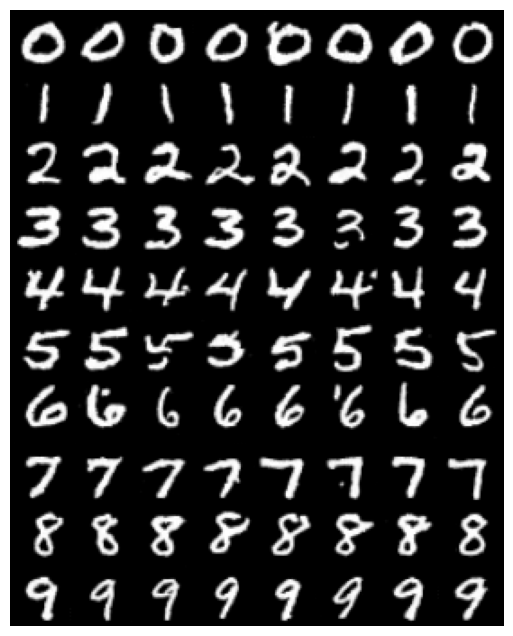

In [18]:
ode = util.CFGVectorFieldODE(net, guidance_scale=3.0)
simulator = util.EulerSimulator(ode)

labels = torch.arange(10).repeat_interleave(8).to(device)
x0, _ = path.p_simple.sample(labels.shape[0])
timesteps = torch.linspace(0, 1, 60, device=device).view(1, -1, 1, 1, 1)
ts = timesteps.expand(labels.shape[0], -1, 1, 1, 1)

with torch.no_grad():
    generated = simulator.simulate(x0, ts, y=labels)

grid = make_grid(generated, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
plt.show()

### Sketch-EITZ sketches
We now add a second conditional flow model trained on the Sketch-EITZ subset from the provided archive. The next cells handle data preparation, model training, and sampling for this dataset without changing the earlier MNIST workflow.


In [8]:
from pathlib import Path
import zipfile
import urllib.request

sketch_url = "https://www.dropbox.com/scl/fi/b3mjrt1hg3nutt1ccm9fy/Sketch_EITZ.zip?rlkey=4evzmz0ddb03kb086g7i0lbko&st=7qv3djxm&dl=1"
sketch_data_dir = Path("./data/Sketch_EITZ")
zip_path = sketch_data_dir.parent / "Sketch_EITZ.zip"

if not (sketch_data_dir / "train.txt").exists():
    sketch_data_dir.parent.mkdir(parents=True, exist_ok=True)
    if not zip_path.exists():
        print("Downloading Sketch-EITZ subset (~100 MB)...")
        urllib.request.urlretrieve(sketch_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(sketch_data_dir.parent)
    print(f"Dataset extracted to {sketch_data_dir.resolve()}")
else:
    print(f"Dataset already available at {sketch_data_dir.resolve()}")


Dataset already available at /media/delas/RetinaRX/Diplomados/Flow Matching/flow_and_diffusion/data/Sketch_EITZ


In [20]:
from PIL import Image

class SketchEitzSampler(nn.Module, util.Sampleable):
    def __init__(self, root="./data/Sketch_EITZ", split="train", image_size=64, n_classes=None):
        super().__init__()
        self.root, self.split, self.size = Path(root), split, image_size
        split_file = self.root / f"{split}.txt"
        if not split_file.exists():
            raise FileNotFoundError(f"Missing {split_file}")
        def read_pairs(path):
            with open(path) as f:
                return [line.strip().split("\t") for line in f if line.strip()]
        entries = read_pairs(split_file)
        pairs = [(self.root / p, int(lbl)) for p, lbl in entries if (self.root / p).exists()]
        if not pairs:
            raise RuntimeError(f"No images found in {self.root}")
        counts = {}
        for _, lbl in pairs:
            counts[lbl] = counts.get(lbl, 0) + 1

        top = sorted(counts, key=lambda k: (-counts[k], k))
        if n_classes:
            top = top[:n_classes]
        id_map = {lbl: i for i, lbl in enumerate(top)}
        self.samples = [(path, id_map[lbl]) for path, lbl in pairs if lbl in id_map]
        if not self.samples:
            raise RuntimeError("Not enough data after filtering top classes")
        self.num_classes = len(id_map)
        mapping = self.root / "mapping.txt"
        self.class_names = None
        if mapping.exists():
            raw_names = {int(idx): name for name, idx in read_pairs(mapping) if idx.isdigit()}
            self.class_names = [raw_names.get(lbl, str(lbl)) for lbl in top[:self.num_classes]]
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((self.size, self.size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])
        self.register_buffer("device_ref", torch.zeros(1))

    def sample(self, num_samples: int):
        if num_samples > len(self.samples):
            raise ValueError(f"num_samples exceeds dataset size: {len(self.samples)}")
        idx = torch.randperm(len(self.samples))[:num_samples]
        images, labels = [], []
        for i in idx.tolist():
            path, label = self.samples[i]
            with Image.open(path) as img:
                images.append(self.transform(img))
            labels.append(label)
        batch = torch.stack(images).to(self.device_ref.device)
        labels = torch.tensor(labels, dtype=torch.int64, device=self.device_ref.device)
        return batch, labels


### Inspect the sketch data
Grab a random batch of sketches to verify preprocessing and label handling.


Classes: ['nose', 'chair', 'socks', 'chair', 'standing_bird', 'armchair', 'standing_bird', 'armchair', 'door', 'door', 'lighter', 'nose', 'nose', 'standing_bird', 'bell', 'chair', 'armchair', 'standing_bird', 'lighter', 'teddy-bear', 'door', 'blimp', 'bell', 'teddy-bear', 'teddy-bear', 'door', 'lighter', 'lighter', 'standing_bird', 'chair', 'nose', 'standing_bird']


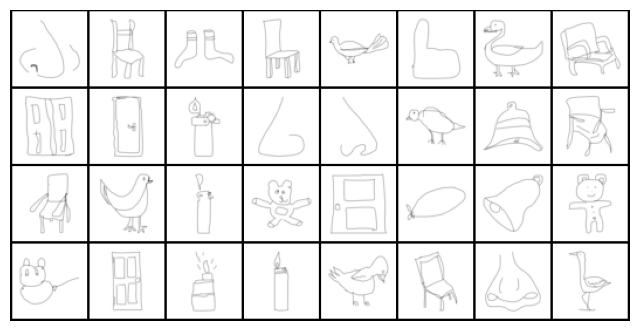

In [21]:
sketch_sampler = SketchEitzSampler(n_classes=10).to(device)
sketch_images, sketch_labels = sketch_sampler.sample(32)
sketch_grid = make_grid(sketch_images, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(8, 8))
plt.imshow(sketch_grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
if sketch_sampler.class_names is not None:
    label_names = [sketch_sampler.class_names[idx] for idx in sketch_labels.cpu().tolist()]
    print("Classes:", label_names)
else:
    print("Label indices:", sketch_labels.cpu().tolist())
plt.show()


### Train a Sketch-EITZ flow model
We reuse the same probability path but introduce helper classes that support an arbitrary number of categories before running the flow matching trainer.


In [22]:
class SketchCFGTrainer(util.Trainer):
    def __init__(self, path, model, eta, null_label):
        super().__init__(model)
        self.path, self.eta, self.null_label = path, eta, int(null_label)

    def get_train_loss(self, batch_size: int):
        z, y = self.path.p_data.sample(batch_size)
        y = y.clone()
        y[torch.rand(y.shape[0], device=y.device) < self.eta] = self.null_label
        t = torch.rand(batch_size, 1, 1, 1, device=z.device)
        x = self.path.sample_conditional_path(z, t)
        ut_theta = self.model(x, t, y)
        ut_ref = self.path.conditional_vector_field(x, z, t)
        return ((ut_theta - ut_ref) ** 2).flatten(start_dim=1).mean()

class SketchCFGODE(util.ODE):
    def __init__(self, net, null_label, guidance_scale=1.0):
        self.net, self.null_label, self.guidance_scale = net, int(null_label), guidance_scale

    def drift_coefficient(self, x, t, y):
        unguided = self.net(x, t, torch.full_like(y, self.null_label))
        guided = self.net(x, t, y)
        return unguided + self.guidance_scale * (guided - unguided)


In [23]:
sketch_image_size = 64
sketch_path = ProbabilityPath(
    p_data=sketch_sampler,
    p_simple_shape=[1, sketch_image_size, sketch_image_size],
    alpha=util.LinearAlpha(),
    beta=util.LinearBeta(),
).to(device)

sketch_net = unet.MNISTUNet(
    channels=[32, 64, 128],
    num_residual_layers=2,
    t_embed_dim=64,
    y_embed_dim=64,
)
sketch_num_classes = sketch_sampler.num_classes
sketch_net.y_embedder = nn.Embedding(sketch_num_classes + 1, 64)
sketch_net = sketch_net.to(device)

print(f"Sketch-EITZ classes: {sketch_num_classes}")
print(f"Model size: {sum(p.numel() for p in sketch_net.parameters()) / 1e6:.2f} million parameters")

sketch_trainer = SketchCFGTrainer(
    path=sketch_path,
    model=sketch_net,
    eta=0.1,
    null_label=sketch_num_classes,
)
sketch_trainer.train(
    num_epochs=5000,
    device=device,
    lr=1e-3,
    batch_size=128,
)


Sketch-EITZ classes: 10
Model size: 1.31 million parameters
Training model with size: 5.025 MiB


Epoch 4999, loss: 0.038: : 5000it [12:52,  6.47it/s]


In [26]:
torch.save(sketch_net.state_dict(), "./Sketch-EITZ.pt")

### Sample new sketches
We follow the learned flow to generate new sketches for a few categories with classifier-free guidance.


100%|██████████████████████████████████████████| 79/79 [00:00<00:00, 106.02it/s]


Displayed classes: ['bell', 'lighter', 'socks', 'standing_bird']


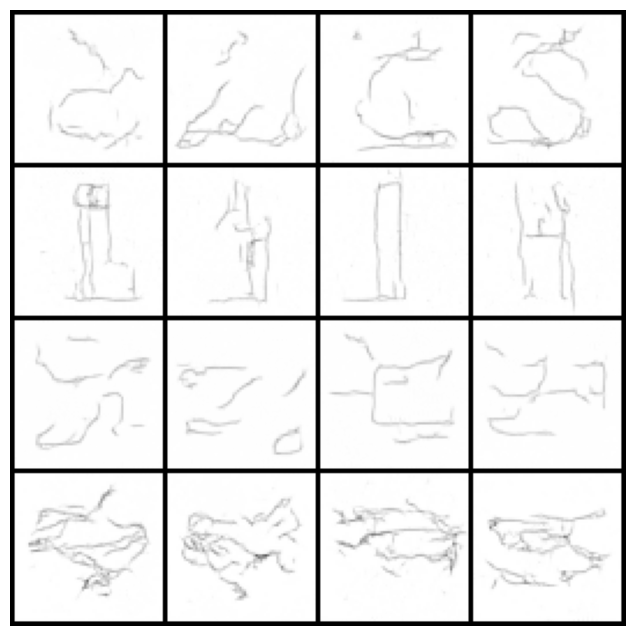

In [24]:
sketch_null_label = sketch_sampler.num_classes
sketch_ode = SketchCFGODE(
    net=sketch_net,
    null_label=sketch_null_label,
    guidance_scale=3.0,
)
sketch_simulator = util.EulerSimulator(sketch_ode)

classes_to_show = min(4, sketch_sampler.num_classes)
samples_per_class = 4
sketch_labels = torch.arange(classes_to_show).repeat_interleave(samples_per_class).to(device)

x0, _ = sketch_path.p_simple.sample(sketch_labels.shape[0])
timesteps = torch.linspace(0, 1, 80, device=device).view(1, -1, 1, 1, 1)
ts = timesteps.expand(sketch_labels.shape[0], -1, 1, 1, 1)

with torch.no_grad():
    sketch_generated = sketch_simulator.simulate(x0, ts, y=sketch_labels)

sketch_grid = make_grid(sketch_generated, nrow=samples_per_class, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(samples_per_class * 2, classes_to_show * 2))
plt.imshow(sketch_grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
if sketch_sampler.class_names is not None:
    displayed = [sketch_sampler.class_names[idx] for idx in torch.arange(classes_to_show).tolist()]
    print("Displayed classes:", displayed)
plt.show()


chair


100%|██████████████████████████████████████████| 79/79 [00:00<00:00, 121.88it/s]


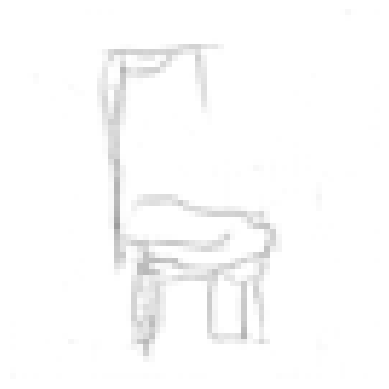

In [40]:
label = 8 #0 #4

print(sketch_sampler.class_names[label])
label = torch.as_tensor(label, device=device).view(1)

B = label.shape[0]
x0, _ = sketch_path.p_simple.sample(B)
timesteps = torch.linspace(0, 1, 80, device=device).view(1, -1, 1, 1, 1)
ts = timesteps.expand(B, -1, 1, 1, 1)

with torch.no_grad():
    sketch_generated = sketch_simulator.simulate(x0, ts, y=label)  # [B, C, H, W]

sketch_grid = make_grid(sketch_generated, nrow=1, normalize=True, value_range=(-1, 1))
img = sketch_grid.permute(1, 2, 0).cpu().numpy()  # CHW -> HWC

# Si es 1 canal, usa cmap; si son 3 canales, no lo fuerces a gris
plt.imshow(img.squeeze(), cmap="gray" if img.shape[-1] == 1 else None)
plt.axis("off")
plt.show()
